### GRUPO #2
Anthony Flores Tomala

Karolayn Calva Jimenez

Marbel Cordova San Lucas

Joyce Paredes Chavez

Jorge Saltos Vera

In [ ]:
import zipfile
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models, datasets
import pandas as pd
import os
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch.nn.functional as F

In [ ]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Descomprimir el archivo zip
zip_path = '/content/drive/MyDrive/G2-classifier-cafe.zip'
extract_path = '/content/dataset'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Cargar el archivo CSV
import pandas as pd
csv_path = '/content/dataset/Coffee Bean.csv'
df = pd.read_csv(csv_path)

# Descripción del Dataset y Pre-procesamiento

In [ ]:
#Descripción del Dataset
print("Tamaño de la imagen: 224 x 224")
print("Número de clases:", df['class index'].nunique())
print("Clases y su significado:")
print(df[['class index', 'labels']].drop_duplicates())

Tamaño de la imagen: 224 x 224
Número de clases: 4
Clases y su significado:
     class index  labels
0              0    Dark
300            1   Green
600            2   Light
900            3  Medium


Tamaño de la Imagen: Todas las imágenes en el conjunto de datos tienen un tamaño de 224 x 224 píxeles. Esta información es importante para entender las dimensiones de las imágenes que se utilizarán como entrada para el modelo.

Número de Clases: El conjunto de datos contiene un total de clases únicas, cada una representando una categoría específica de granos de café. Esta información es vital para determinar la cantidad de salidas necesarias en la capa final del modelo.

Clases y su Significado: Se muestra una tabla que enumera las clases y sus correspondientes índices. Cada clase tiene un significado asociado, y en este caso, estas clases representan diferentes categorías de granos de café, como 'Dark', 'Green', 'Light', y 'Medium'.

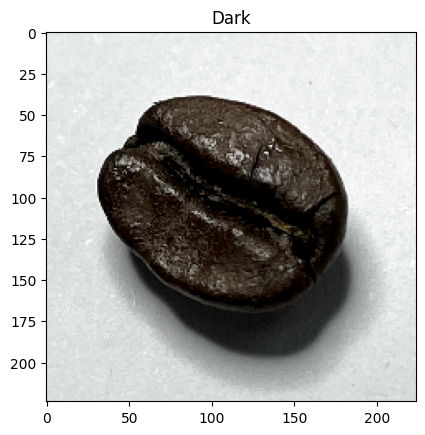

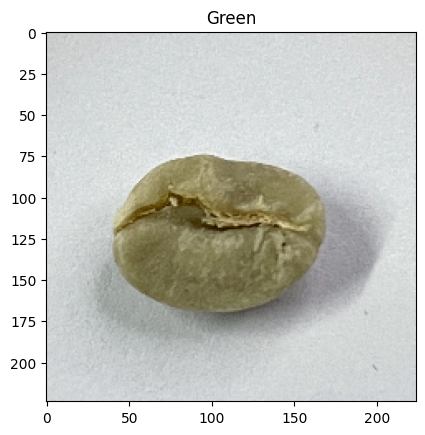

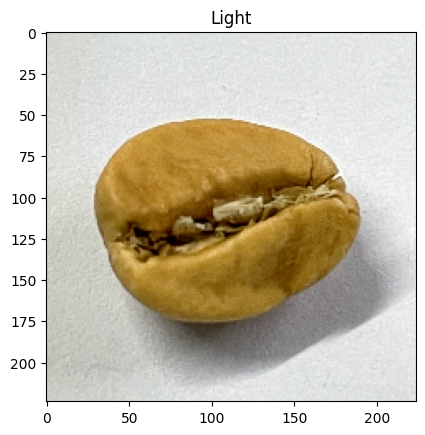

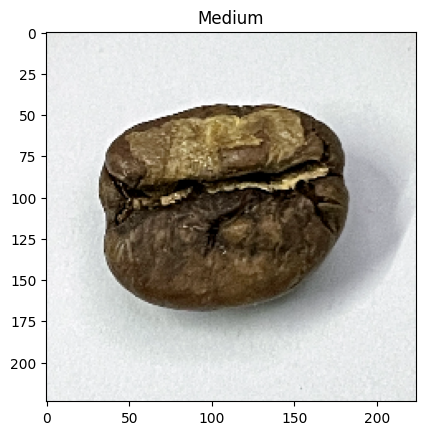

In [ ]:
# Mostrar algunas imágenes de cada clase
classes = df['labels'].unique()

for cls in classes:
    class_path = os.path.join('/content/dataset/train', cls)
    img_file = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, img_file)

    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(cls)
    plt.show()

Obtención de Clases Únicas: classes = df['labels'].unique() obtiene la lista de clases únicas presentes en el conjunto de datos. Estas clases representan las categorías de granos de café, como 'Dark', 'Green', 'Light', y 'Medium'.

Iteración y Visualización: Para cada clase, se construye la ruta del directorio que contiene las imágenes correspondientes a esa clase en el conjunto de entrenamiento (class_path). Luego, se elige arbitrariamente la primera imagen de esa clase (img_file = os.listdir(class_path)[0]) y se construye la ruta completa de la imagen (img_path).

Visualización con Matplotlib: Se carga la imagen seleccionada con PIL (img = Image.open(img_path)) y se utiliza Matplotlib para mostrar la imagen junto con el título de la clase (plt.imshow(img), plt.title(cls), plt.show()).

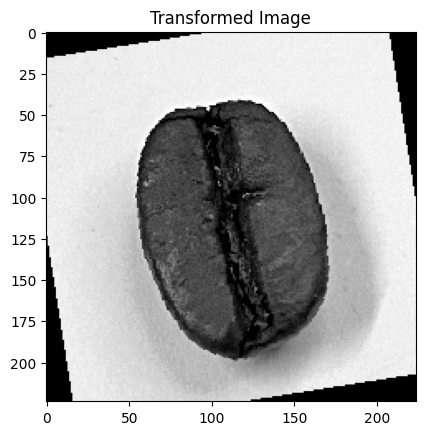

In [ ]:
# Pre-procesamiento
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomCrop(224),
    transforms.RandomRotation(degrees=45),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.Grayscale(1),  # Asegura que la imagen tenga 1 canal (escala de grises)
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
# Ejemplo de aplicación de transformaciones
example_img = Image.open(os.path.join('/content/dataset/train/Dark', 'dark (1).png'))
transformed_img = transform(example_img)
# Visualizar la imagen transformada
plt.imshow(transformed_img[0], cmap='gray')
plt.title('Transformed Image')
plt.show()

Definición de Transformaciones: transform = transforms.Compose([...]) define una secuencia de transformaciones que se aplicarán a las imágenes. Estas transformaciones incluyen el cambio de tamaño a 224x224 píxeles, recorte aleatorio a 224x224 píxeles, rotación aleatoria de hasta 45 grados, volteo horizontal y vertical, conversión a escala de grises (1 canal), conversión a tensor y normalización.

Carga de una Imagen de Ejemplo: example_img = Image.open(os.path.join('/content/dataset/train/Dark', 'dark (1).png')) carga una imagen de ejemplo del conjunto de entrenamiento. En este caso, se carga una imagen de la clase 'Dark'.

Aplicación de Transformaciones: transformed_img = transform(example_img) aplica las transformaciones definidas previamente a la imagen de ejemplo.

Visualización de la Imagen Transformada: plt.imshow(transformed_img[0], cmap='gray') utiliza Matplotlib para mostrar la imagen transformada. Dado que la transformación a escala de grises produce un tensor de forma (1, 224, 224), se accede a la primera dimensión (transformed_img[0]) para visualizar la imagen.

# Análisis Exploratorio

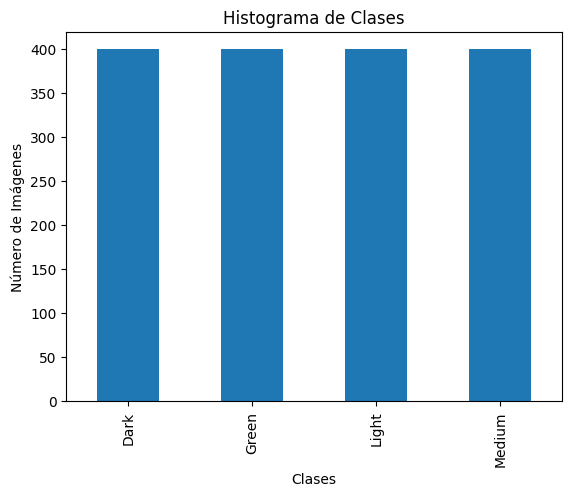

In [ ]:
# Gráfico de Histograma de las clases en el conjunto de entrenamiento
df['labels'].value_counts().plot(kind='bar')
plt.title('Histograma de Clases')
plt.xlabel('Clases')
plt.ylabel('Número de Imágenes')
plt.show()

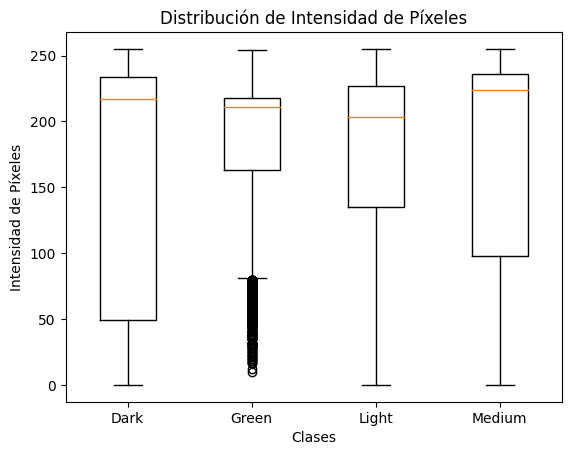

In [ ]:
# Boxplot de la distribución de intensidad de píxeles
pixel_values = []
for cls in classes:
    class_path = os.path.join('/content/dataset/train', cls)
    img_file = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, img_file)

    img = Image.open(img_path).convert('L')  # Convertir a escala de grises
    pixel_values.append(img.getdata())

# Boxplot
plt.boxplot(pixel_values, labels=classes)
plt.title('Distribución de Intensidad de Píxeles')
plt.xlabel('Clases')
plt.ylabel('Intensidad de Píxeles')
plt.show()

Este gráfico es útil para visualizar la variabilidad en la intensidad de píxeles entre las diferentes clases del conjunto de datos. Puede ayudar a identificar patrones o características distintivas en la distribución de intensidades de píxeles de las imágenes.

# Diseño de la Arquitectura CNN con PyTorch

In [ ]:
# Asegurarse de que la GPU esté disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define la arquitectura CNN usando ResNet18
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 56 * 56, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 56 * 56)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Mueve el modelo a la GPU
simple_model = SimpleCNN().to(device)

**Capa de Convolución 1 (conv1):**

Tamaño de Kernel: 3x3
Número de Canales de Entrada: 1 (escala de grises)
Número de Filtros: 32
Tamaño de Relleno (Padding): 1
Operación de Convolución: conv1_output=Conv2d(x,kernel_size=3,padding=1,out_channels=32)

**Función de Activación ReLU después de la Convolución 1:**

Operación de Activación:
x=ReLU(conv1_output)

**Capa de Max Pooling después de la Convolución 1:**

Tamaño del Kernel de Max Pooling: 2x2
Stride del Max Pooling: 2
Operación de Max Pooling:
x=MaxPool2d(x,kernel_size=2,stride=2)

**Capa de Convolución 2 (conv2):**

Tamaño de Kernel: 3x3
Número de Canales de Entrada: 32 (salida de la conv1)
Número de Filtros: 64
Tamaño de Relleno (Padding): 1
Operación de Convolución:
conv2_output=Conv2d(x,kernel_size=3,padding=1,out_channels=64)

**Función de Activación ReLU después de la Convolución 2:**

Operación de Activación:
x=ReLU(conv2_output)

**Capa de Max Pooling después de la Convolución 2:**

Tamaño del Kernel de Max Pooling: 2x2
Stride del Max Pooling: 2
Operación de Max Pooling:
x=MaxPool2d(x,kernel_size=2,stride=2)

**Aplanamiento de la Salida para la Capa Totalmente Conectada (fc1):**

Operación de Aplanamiento:
x=view(x,(−1,64×56×56))

**Capa Totalmente Conectada 1 (fc1):**

Número de Neuronas de Entrada: 64 * 56 * 56
Número de Neuronas de Salida: 512
Operación de Capa Totalmente Conectada:
fc1_output=Linear(x,in_features=64×56×56,out_features=512)

**Función de Activación ReLU después de la Capa Totalmente Conectada 1:**

Operación de Activación:
x=ReLU(fc1_output)

**Capa Totalmente Conectada 2 (fc2):**

Número de Neuronas de Entrada: 512
Número de Neuronas de Salida: Número de Clases (4 en este caso)
Operación de Capa Totalmente Conectada:
fc2_output=Linear(x,in_features=512,out_features=4)

**Salida Final:**

La salida final es la salida de la Capa Totalmente Conectada 2 (fc2):
output=fc2_output

In [ ]:
# Define la función de pérdida y el optimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(simple_model.parameters(), lr=0.001)

# Función de entrenamiento
def train_model(model, train_loader, criterion, optimizer, num_epochs=60):
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        progress_bar = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs}', dynamic_ncols=True)

        for i, (inputs, labels) in enumerate(progress_bar):
            # Mueve los datos a la GPU
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

            progress_bar.set_postfix({'Loss': running_loss / (i + 1)})

    print(f'Epoch {epoch + 1}/{num_epochs}, Loss: {running_loss / len(train_loader)}')

# Directorio de datos
train_data_dir = '/content/dataset/train'
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomCrop(224),
    transforms.RandomRotation(degrees=45),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.Grayscale(1),  # Asegura que la imagen tenga 1 canal (escala de grises)
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Cargar el conjunto de datos directamente desde las carpetas
train_dataset = datasets.ImageFolder(root=train_data_dir, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Entrenar el modelo
train_model(simple_model, train_loader, criterion, optimizer, num_epochs=60)

Epoch 60/60: 100%|██████████| 19/19 [00:06<00:00,  3.11it/s, Loss=0.211]

Epoch 60/60, Loss: 0.21141899298680455


**Este código se encarga de entrenar un modelo de CNN para la clasificación de imágenes y muestra el progreso en términos de pérdida por época. Además, está configurado para ejecutarse en la GPU si está disponible, lo que debería acelerar significativamente el entrenamiento.**

Se utiliza la función de pérdida CrossEntropyLoss, que es comúnmente utilizada para problemas de clasificación.

El optimizador Adam se utiliza para ajustar los pesos del modelo durante el entrenamiento. La tasa de aprendizaje se establece en 0.001.

La función train_model toma como entrada el modelo, el conjunto de datos de entrenamiento (train_loader), la función de pérdida, el optimizador y el número de épocas.

El modelo se coloca en el modo de entrenamiento (model.train()).
Se itera a través de cada época y cada lote en el conjunto de datos de entrenamiento.

Los datos se mueven a la GPU si está disponible.
Se realiza la propagación hacia adelante, el cálculo de la pérdida, la propagación hacia atrás y la actualización de los pesos del modelo.

La barra de progreso se actualiza para mostrar la pérdida en tiempo real.
Se definen las transformaciones de preprocesamiento de imágenes utilizando transforms.Compose.

Se carga el conjunto de datos utilizando datasets.ImageFolder.
El modelo se entrena llamando a la función train_model con el modelo, el cargador de datos de entrenamiento, la función de pérdida, el optimizador y el número de épocas.


# Prueba de predicción del modelo vs la imagen real

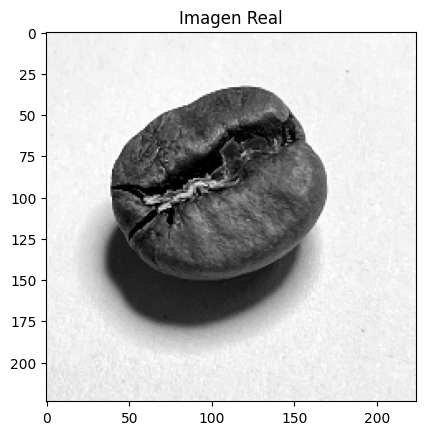

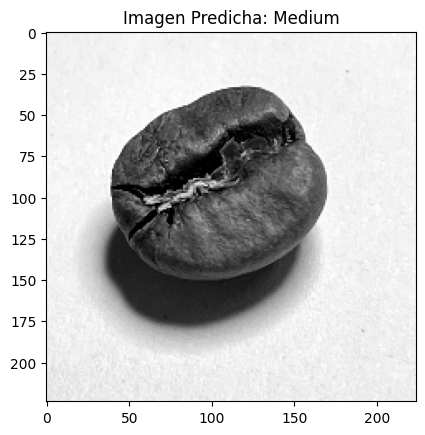

Clase Real: Medium
Clase Predicha: Medium


In [ ]:
# Ruta de la imagen a predecir
test_img_path = '/content/dataset/test/Medium/medium (38).png'

# Cargar la imagen real sin cambios
real_img = Image.open(test_img_path).convert('L')  # Convertir a escala de grises

# Mostrar la imagen real
plt.imshow(real_img, cmap='gray')
plt.title('Imagen Real')
plt.show()

# Preprocesar la imagen para la predicción
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(1),  # Asegura que la imagen tenga 1 canal (escala de grises)
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

transformed_test_img = transform(real_img).unsqueeze(0)

# Ajustar el dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Mover el modelo a la GPU si está disponible
simple_model = simple_model.to(device)

# Mover los datos a la GPU si está disponible
transformed_test_img = transformed_test_img.to(device)

# Hacer una predicción con el modelo
simple_model.eval()
with torch.no_grad():
    output = simple_model(transformed_test_img)
    predicted_class = torch.argmax(output).item()

# Mapeo de clases
class_mapping = {
    0: 'Dark',
    1: 'Green',
    2: 'Light',
    3: 'Medium'
}

# Mostrar la imagen predicha
plt.imshow(real_img, cmap='gray')
plt.title(f'Imagen Predicha: {class_mapping[predicted_class]}')
plt.show()

# Imprimir la clase real y predicha
print(f'Clase Real: {test_img_path.split("/")[-2]}')
print(f'Clase Predicha: {class_mapping[predicted_class]}')

Este bloque de código proporciona una forma de verificar visualmente cómo se desempeña el modelo en una imagen de prueba específica. Si la predicción y la clase real coinciden... el modelo está haciendo predicciones precisas.

**Ruta de la Imagen a Predecir:**

Se proporciona la ruta de la imagen que se desea predecir (test_img_path).

**Cargar la Imagen Real:**

La imagen real se carga sin realizar cambios (real_img).
Se muestra la imagen real en escala de grises.

**Preprocesamiento de la Imagen para la Predicción:**

Se aplica un conjunto de transformaciones a la imagen de prueba para que coincida con el formato de entrada esperado por el modelo.
Se utiliza transforms.Compose para aplicar varias transformaciones, como redimensionamiento, conversión a escala de grises, y normalización.

**Mover el Modelo y los Datos a la GPU:**

Se verifica si la GPU está disponible.
El modelo y los datos de prueba se mueven a la GPU si está disponible.

**Hacer una Predicción con el Modelo:**

El modelo preentrenado se coloca en modo de evaluación (simple_model.eval()).
Se realiza la predicción de la imagen de prueba.

**Mapeo de Clases:**

Se define un mapeo de clases para traducir los índices de clases predichos en nombres más legibles.

**Mostrar la Imagen Predicha:**

Se muestra la imagen de prueba junto con el título que indica la clase predicha por el modelo.

**Imprimir la Clase Real y Predicha:**

Se imprime la clase real obtenida de la ruta de la imagen y la clase predicha.